In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt


### Diabetes Prediction

In [32]:
data = load_diabetes(as_frame=True,scaled=False)

x = data.data
y = data.target

df = pd.concat([x,y],axis=1)
df.rename({0:'target'},inplace = True)

print(df.head(20))

         age  sex   bmi     bp     s1     s2    s3    s4      s5    s6  target
target  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.00  4.8598  87.0   151.0
1       48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.00  3.8918  69.0    75.0
2       72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.00  4.6728  85.0   141.0
3       24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.00  4.8903  89.0   206.0
4       50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.00  4.2905  80.0   135.0
5       23.0  1.0  22.6   89.0  139.0   64.8  61.0  2.00  4.1897  68.0    97.0
6       36.0  2.0  22.0   90.0  160.0   99.6  50.0  3.00  3.9512  82.0   138.0
7       66.0  2.0  26.2  114.0  255.0  185.0  56.0  4.55  4.2485  92.0    63.0
8       60.0  2.0  32.1   83.0  179.0  119.4  42.0  4.00  4.4773  94.0   110.0
9       29.0  1.0  30.0   85.0  180.0   93.4  43.0  4.00  5.3845  88.0   310.0
10      22.0  1.0  18.6   97.0  114.0   57.6  46.0  2.00  3.9512  83.0   101.0
11      56.0  2.0  28.0   85.0  184.0  144.8  32.0  

#Features
#data.columns = ['Age','Sex','Bmi','Bp','Tc','Ldl','Hdl','Tch','Ltg','Glu']
#bmi:body mass index,bp:average blood pleasure,tc:total cherun cholesterol
#ldl:low-density liproteins,hdl:high-density liproteins,tch:total cholesterol
#lgt:possibly log of serum triglycerides level,glu:blood sugar level


## Clean and Eda

In [33]:
df.describe(),df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 442 entries, target to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 41.4+ KB


(              age         sex         bmi          bp          s1          s2  \
 count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
 mean    48.518100    1.468326   26.375792   94.647014  189.140271  115.439140   
 std     13.109028    0.499561    4.418122   13.831283   34.608052   30.413081   
 min     19.000000    1.000000   18.000000   62.000000   97.000000   41.600000   
 25%     38.250000    1.000000   23.200000   84.000000  164.250000   96.050000   
 50%     50.000000    1.000000   25.700000   93.000000  186.000000  113.000000   
 75%     59.000000    2.000000   29.275000  105.000000  209.750000  134.500000   
 max     79.000000    2.000000   42.200000  133.000000  301.000000  242.400000   
 
                s3          s4          s5          s6      target  
 count  442.000000  442.000000  442.000000  442.000000  442.000000  
 mean    49.788462    4.070249    4.641411   91.260181  152.133484  
 std     12.934202    1.290450    0.522391   11.49633

- In a problem like this,we want to see how variables can affect others and what their weights or importances in that processes.in our case,we want to predict diabetes develop according patient caracteristics.

for discover it,let's look at variables relations first.

<Axes: >

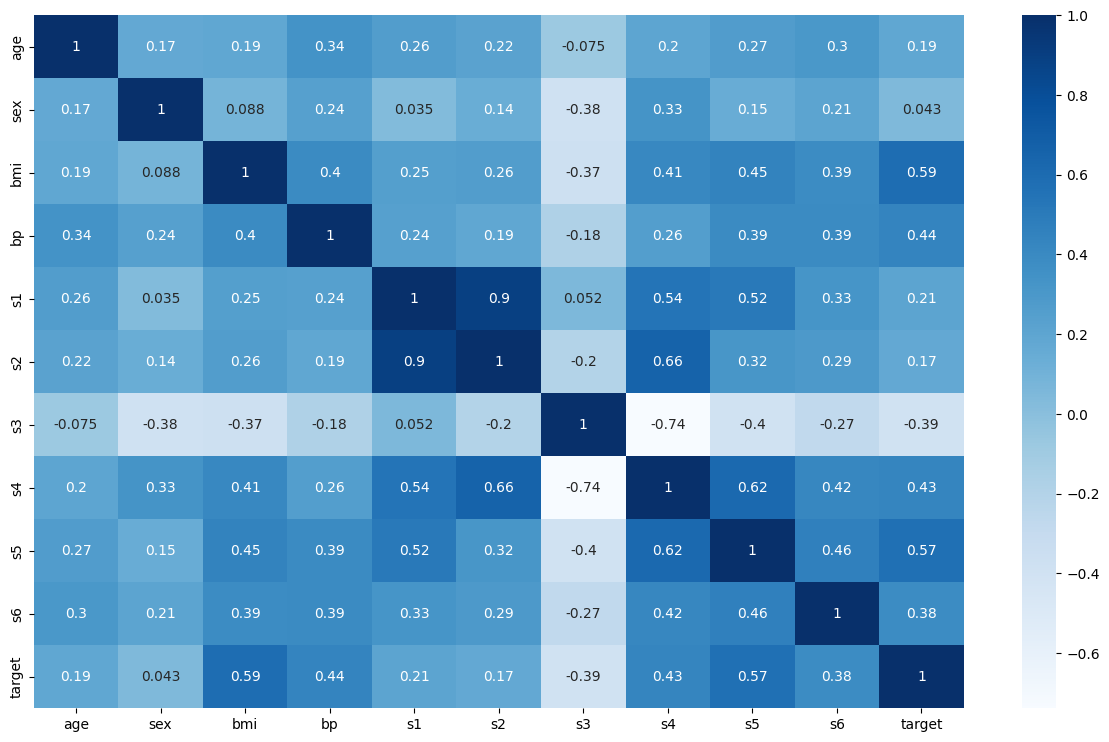

In [34]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(),cmap='Blues',annot=True)

In [35]:
df.corr()['target'].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

This means that __body mass index__ and __Triglicerydes__ are most correlationed with diabetes progression.

Let's create ranges category with pd.cut for *bmi* and *s5* and see diabetes progression for each class:

In [36]:
bmi_1 = [min(df['bmi']),  df['bmi'].quantile(0.15),df['bmi'].quantile(0.5),df['bmi'].quantile(0.85) , max(df['bmi'])]
s5_1 = [min(df['s5']) , df['s5'].quantile(0.15),df['s5'].quantile(0.5),df['s5'].quantile(0.85), max(df['s5'])]


df['bmi_cat'] = pd.cut(df['bmi'],bins = bmi_1,
labels = ['min_bmi','low_bmi','medium_bmi','high_bmi'])

df['s5_cat'] = pd.cut(df['s5'],bins = s5_1,
labels = ['min_s5','low_s5','medium_s5','high_s5'])

In [37]:
print(df[df['bmi_cat']=='high_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='medium_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='min_bmi']['bmi'].mean())
print(df[df['bmi_cat']=='low_bmi']['bmi'].mean())

33.915151515151514
28.209150326797385
20.47462686567164
23.960645161290326


In [38]:
df.head(30)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,bmi_cat,s5_cat
target,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0,high_bmi,medium_s5
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0,min_bmi,min_s5
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0,medium_bmi,medium_s5
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0,low_bmi,medium_s5
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0,low_bmi,low_s5
5,23.0,1.0,22.6,89.00,139.0,64.8,61.0,2.00,4.1897,68.0,97.0,low_bmi,low_s5
6,36.0,2.0,22.0,90.00,160.0,99.6,50.0,3.00,3.9512,82.0,138.0,min_bmi,min_s5
7,66.0,2.0,26.2,114.00,255.0,185.0,56.0,4.55,4.2485,92.0,63.0,medium_bmi,low_s5
8,60.0,2.0,32.1,83.00,179.0,119.4,42.0,4.00,4.4773,94.0,110.0,high_bmi,low_s5
9,29.0,1.0,30.0,85.00,180.0,93.4,43.0,4.00,5.3845,88.0,310.0,medium_bmi,high_s5


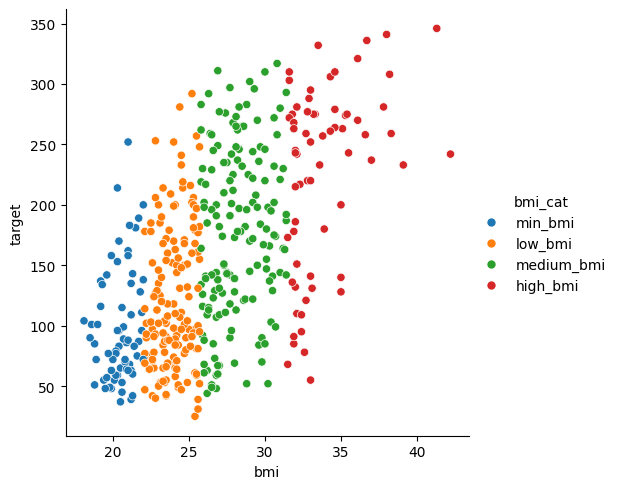

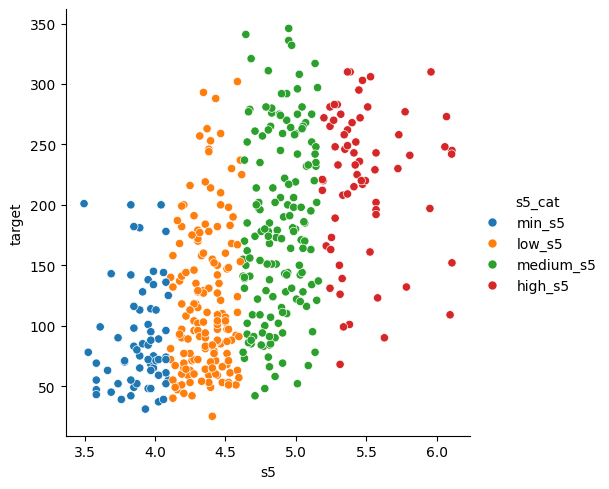

In [39]:
sns.relplot(data=df,x='bmi',y='target',hue='bmi_cat',kind='scatter')
sns.relplot(data=df,x='s5',y='target',hue='s5_cat',kind='scatter')

- So as you see,the level of **s5** and **bmi** don't change sick progression.

In previous heatmap,we've seem that **s4** and **sex** are correlated with **s5** and **bmi**,what can be tested too:


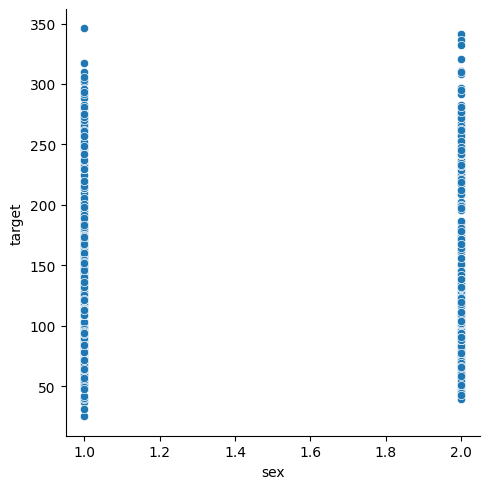

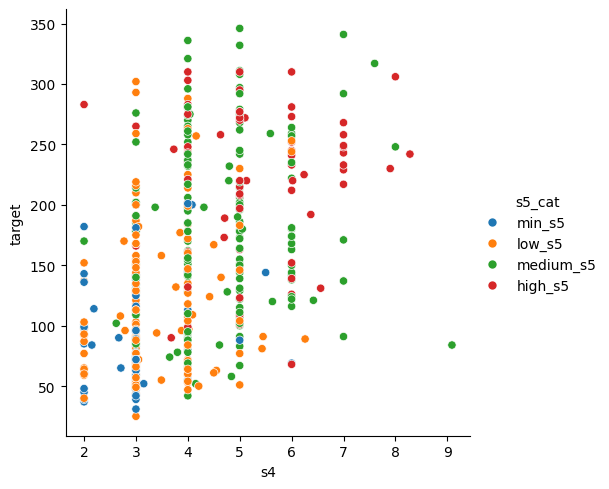

In [40]:
sns.relplot(data=df,x='sex',y='target',kind='scatter')
sns.relplot(data=df,x='s4',y='target',hue='s5_cat',kind='scatter')

- After see relations between indicators,let's compare his counts :


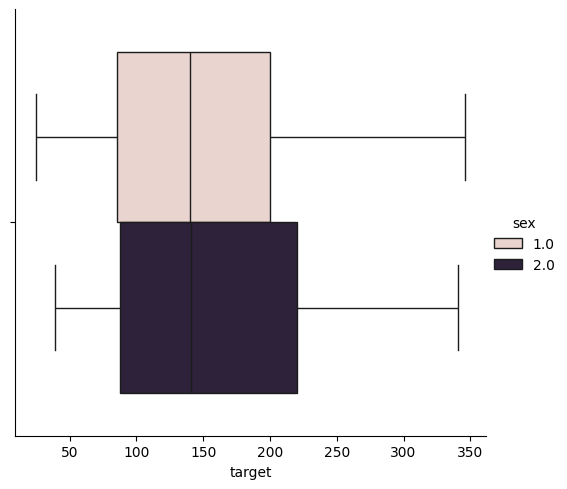

In [41]:
sns.catplot(data=df,x='target',hue='sex',kind='box')

<Axes: xlabel='target', ylabel='Density'>

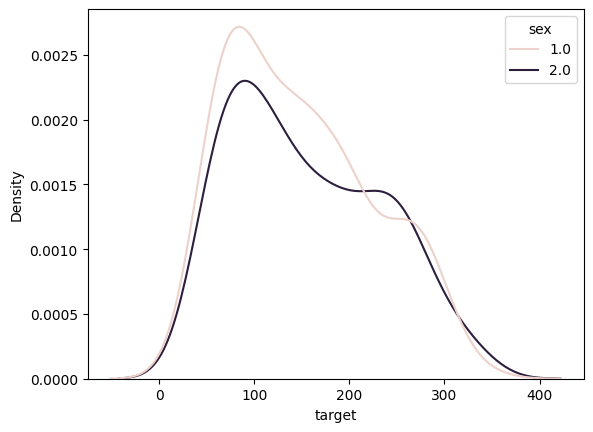

In [42]:
sns.kdeplot(data=df,x='target',hue='sex')

<Axes: xlabel='age', ylabel='target'>

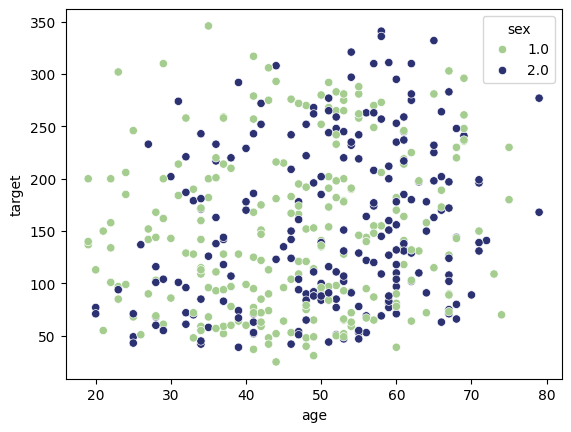

In [43]:
sns.scatterplot(data=df,x='age',y='target',hue='sex',palette='crest')

<Figure size 2000x900 with 0 Axes>

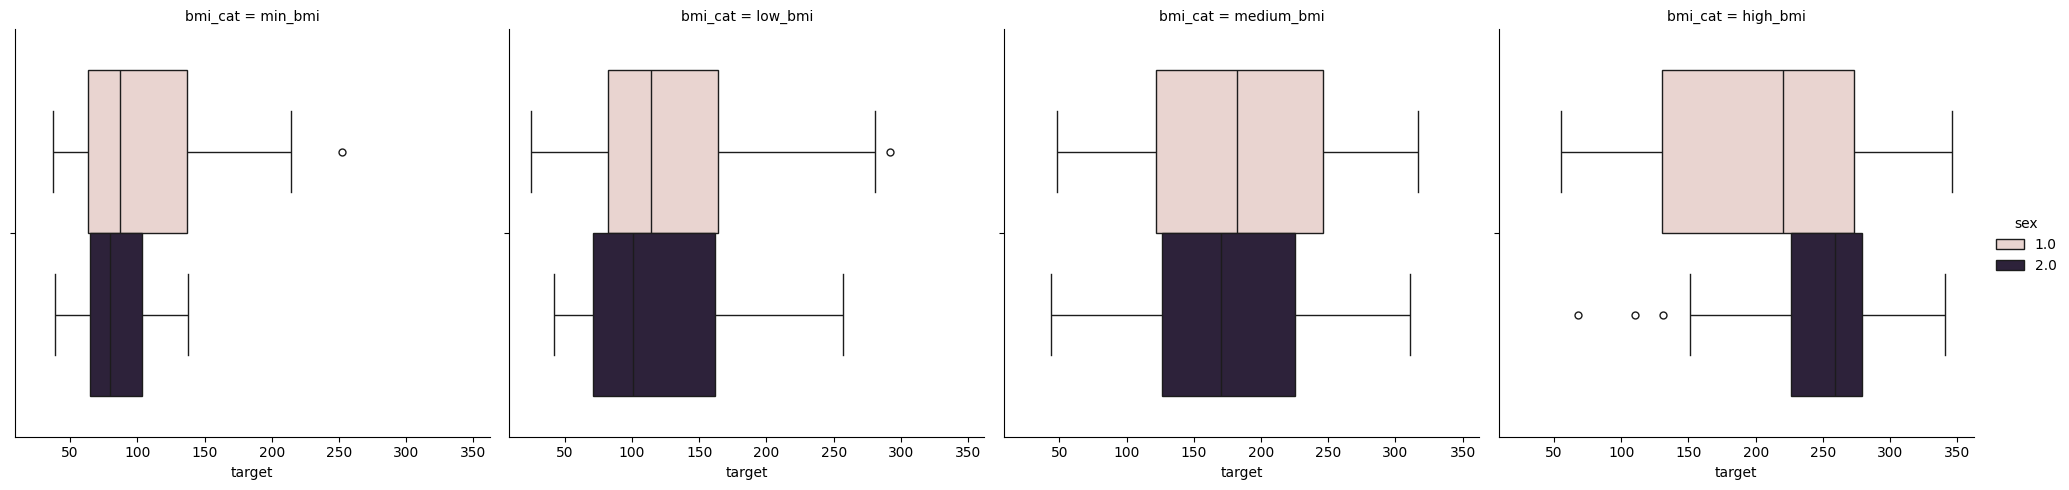

In [44]:
plt.figure(figsize=(20,9))
sns.catplot(data=df,x='target',kind='box',hue='sex',col='bmi_cat')

<Axes: xlabel='age', ylabel='bmi'>

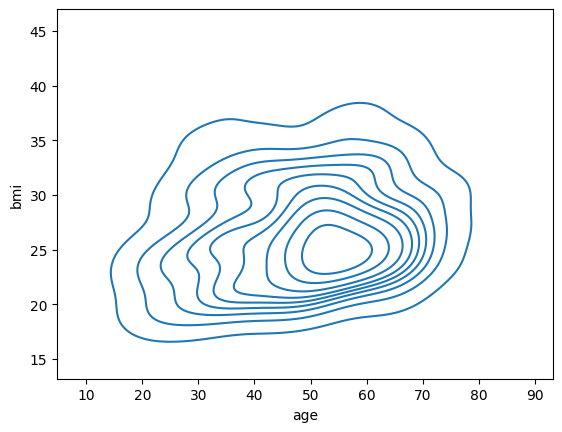

In [45]:
sns.kdeplot(data=df,x='age',y='bmi')

## Stats and Hipotesis Testing
- For a more precise view,we will calculate variables stats and compare them to get insights.this calculations are based on hipotesis that we've created after visualizing data.

#### Questions:

- 1. Bmi levels affects diabetes progression?

- 2. Bmi + Bp are determinants together for diabetes progression?

- 3. Are old people the most heavy?

- 4. Age + Sex affects diabetes progression?

- 5. Blood sugar level and Colesterol affects diabetes?

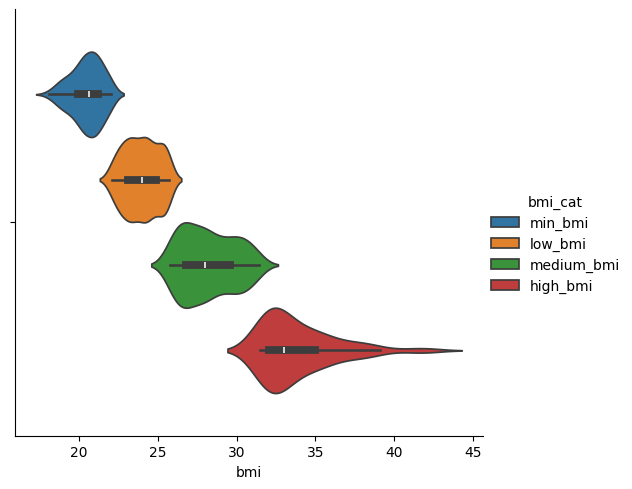

In [46]:
#1: using bmi group means:
bmi_high = df[df['bmi_cat']=='high_bmi']['target']
bmi_medium = df[df['bmi_cat']=='medium_bmi']['target']
bmi_min = df[df['bmi_cat']=='min_bmi']['target']
bmi_low = df[df['bmi_cat']=='low_bmi']['target']

sns.catplot(data=df,x='bmi',hue='bmi_cat',kind ='violin')

- h0 = Bmi not affects diabetes progression ( high_bmi target = low_bmi target)
- h1 = Bmi affects diabetes progression ( high_bmi target > low_bmi target)

In [47]:
from scipy.stats import ttest_ind,f_oneway

max_min_bmi_test = ttest_ind(bmi_low,bmi_high)
print(max_min_bmi_test)

TtestResult(statistic=np.float64(-11.188632636695216), pvalue=np.float64(2.800997028358101e-23), df=np.float64(219.0))


bmi groups have a significant diference and is correlacted with target

In [ ]:
#groups :

bmi_range_test = f_oneway(bmi_min,bmi_low,bmi_medium,bmi_high)
print(bmi_range_test)


F_onewayResult(statistic=np.float64(64.28704826559168), pvalue=np.float64(1.898238184713057e-34))


### Permutation Test

In [49]:
diff_observed = bmi_high.mean() - bmi_low.mean()

#group data
group_combined = np.concatenate([bmi_high,bmi_low])

diffs = [] # for plot distribuition

for i in range (10000):

    np.random.shuffle(group_combined)
    high = group_combined[:len(bmi_high)]
    low = group_combined[len(bmi_low):]

    diffs.append(high.mean() - low.mean())

p_value = np.mean(np.array(diffs) >= diff_observed)

p-val :  0.0


Text(0.5, 1.0, 'Null distribuition')

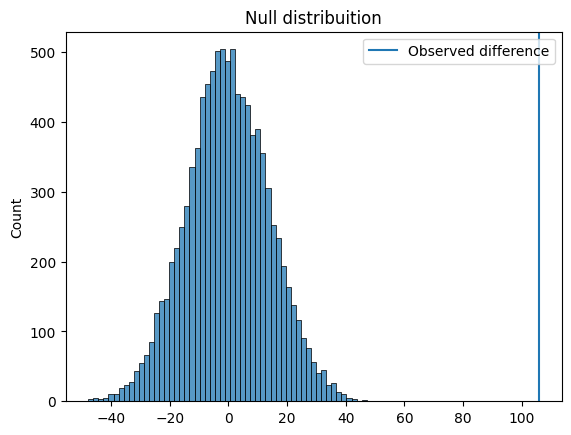

In [50]:
print(f'p-val :  {p_value}')

sns.histplot(x=diffs)
plt.axvline(x=diff_observed,label="Observed difference")
plt.legend()
plt.title('Null distribuition')

Observed difference automatically rejects h0 : high_bmi target =~ low_bmi target

2. Bmi + Bp
- h0 = bmi_bp not affects target
- h1 = bmi_bp affects target

In that cases,we can use a model that meansures features relations like a **Regression** or **F-test**.

In [51]:

df['bp_bmi'] = df['bp'] * df['bmi']
print(df['bp_bmi'].corr(df['target']))

0.6257350256125965


In [52]:
import statsmodels.api as sm

x = df[['bp_bmi']]
x = sm.add_constant(x)

y = df['target']

model1 = sm.OLS(y,x).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     283.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.05e-49
Time:                        16:57:32   Log-Likelihood:                -2437.4
No. Observations:                 442   AIC:                             4879.
Df Residuals:                     440   BIC:                             4887.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.8315     11.244     -2.742      0.0

- bmi per bp has a little influence in diabetes progression

3.Are old people the most heavy?

C:\Users\augusto\AppData\Local\Temp\ipykernel_13780\1115771646.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_class','bmi_cat'])['target'].agg(['mean','std','sum'])


mean        std      sum
age_class bmi_cat                                   
Young     min_bmi      94.892857  45.882331   5314.0
          low_bmi     113.028986  55.918526   7799.0
          medium_bmi  167.106061  73.145404  11029.0
          high_bmi    202.250000  80.949606   6472.0
Old       min_bmi     117.000000  55.269039   1170.0
          low_bmi     124.523810  60.764304  10460.0
          medium_bmi  183.770115  68.205521  15988.0
          high_bmi    248.235294  65.132526   8440.0

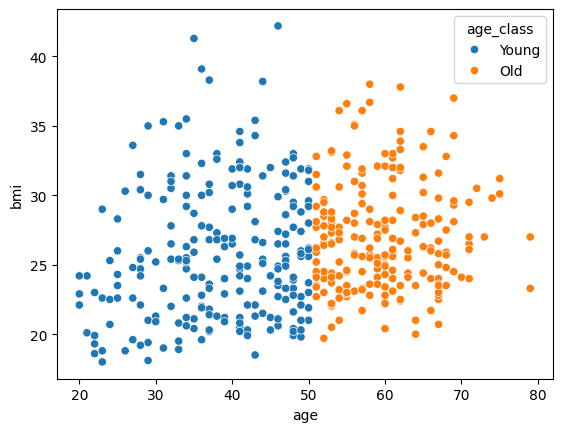

In [53]:
x_groups = df['age'].quantile([0,0.5,1])
x_class = ['Young','Old']
df['age_class'] = pd.cut(df['age'],bins=x_groups,labels=x_class)


sns.scatterplot(x=df['age'],y=df['bmi'],hue = df['age_class'])
df.groupby(['age_class','bmi_cat'])['target'].agg(['mean','std','sum'])


- h0 : old_mean_bmi = young_mean_bmi
- h1 : old_mean_bmi > young_mean_bmi

t_test:

In [54]:
old = df[df['age_class'] =='Old']['bmi']
young = df[df['age_class'] == 'Young']['bmi']

bmi_years = ttest_ind(old,young)
print(bmi_years)

TtestResult(statistic=np.float64(2.6731170101364783), pvalue=np.float64(0.007796337293350275), df=np.float64(437.0))


Old people have more bmi

Permutation:


In [55]:
observed_diff = old.mean() - young.mean()

diffs = []
random_data = np.concatenate([old,young])

for i in range (10000):
    np.random.shuffle(random_data)
    new_old = random_data[:len(old)]
    new_young = random_data[len(young):]
    diffs.append(new_old.mean() - new_young.mean())

p_value = np.mean(np.array(diffs) >= observed_diff) #unilateral test(less,equal on left)
print(f'p_value : {p_value}')

p_value : 0.0058


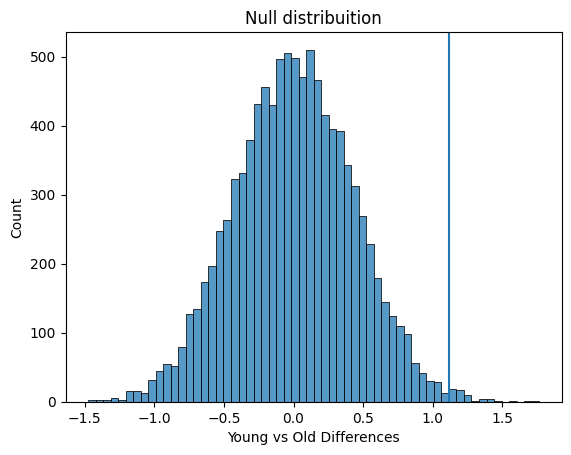

In [56]:
plt.title('Null distribuition')
sns.histplot(x=diffs)
plt.xlabel('Young vs Old Differences')
plt.axvline(observed_diff)


If we assume h0,there's 0.38% of chance of we see the real diference between old and young where : old mean > young > mean 

4. Age + Sex Affects diabetes progression?


In [57]:
x_age_sex = df[['age','sex']]
x_age_sex = sm.add_constant(x_age_sex)
y_age_sex = df['target']

model_age_sex = sm.OLS(y_age_sex,x_age_sex).fit()
print('P vals of each val + model val1-val2')
print(f' p_vals: {(model_age_sex.pvalues)} \n, f_val: {model_age_sex.fvalue}')

P vals of each val + model val1-val2
 p_vals: const    5.215687e-09
age      1.076874e-04
sex      8.215392e-01
dtype: float64 
, f_val: 8.058792462829933


In [58]:
print(f'influence in target (+1 in var = x in target): {model_age_sex.tvalues}')

influence in target (+1 in var = x in target): const    5.958936
age      3.908151
sex      0.225701
dtype: float64


In [59]:
print(model_age_sex.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     8.059
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000365
Time:                        16:57:34   Log-Likelihood:                -2539.2
No. Observations:                 442   AIC:                             5084.
Df Residuals:                     439   BIC:                             5097.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.6213     16.215      5.959      0.0

- Just age has a significative influence in target.so sex is not necessary to predict diabetes.

5. Blood sugar level and Colesterol affects diabetes?



In [61]:
x_bp_s1 = df[['bp','s1']]
x_bp_s1 = sm.add_constant(x_bp_s1)
y_bp_s1 = df['target']

model_bp_s1 = sm.OLS(y_bp_s1,x_bp_s1).fit()
print(model_bp_s1.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     57.16
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           8.64e-23
Time:                        17:06:54   Log-Likelihood:                -2496.0
No. Observations:                 442   AIC:                             4998.
Df Residuals:                     439   BIC:                             5010.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -113.4947     26.058     -4.356      0.0

Both have a strong relation with target.that means that we can use them to meansure diabetes progression.

So let's compare an model with a the joined variables;

In [67]:
x_bp = df['bp']
x_bp = sm.add_constant(x_bp)
y_bp = df['target']

model_bp = sm.OLS(y_bp,x_bp).fit()

f_val,p_val,df_diff = model_bp_s1.compare_f_test(model_bp)
print(f'f_val: {f_val} \n p_val: {p_val} \n diff: {df_diff}')

f_val: 6.478861245919932 
 p_val: 0.011257522040121284 
 diff: 1.0


Before we test ML models and make predictions,let's all compare model hypotesis with diabetes progression: